
# Beer Recommender System — Phase 1

**Dataset:** BeerAdvocate + RateBeer  
**Goal:** Build a clean shared foundation for Phase 1 with:
- unified preprocessing
- simple baselines
- a corrected matrix factorization baseline
- comparable ranking and rating evaluation




## 1. Environment Setup

Run this notebook in Colab or Jupyter. The code below detects GPU automatically.


In [1]:

import os
import ast
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: Apple MPS')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')

print('Active device:', DEVICE)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


GPU: Tesla T4
Active device: cuda



## 2. Data Paths

Choose one option:
- **Colab + Google Drive**
- **Local filesystem**

Set `USE_COLAB_DRIVE = True` only if you are in Colab and want to mount Drive.


In [2]:

USE_COLAB_DRIVE = True

if USE_COLAB_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    BASE_PATH = Path('/content/drive/MyDrive/RCCSYS')
else:
    BASE_PATH = Path('.')

SOURCE_FILES = {
    'beeradvocate': BASE_PATH / 'beeradvocate.json',
    'ratebeer': BASE_PATH / 'ratebeer.json',
}

for name, path in SOURCE_FILES.items():
    print(f"{name:12s} -> {path}")


Mounted at /content/drive
beeradvocate -> /content/drive/MyDrive/RCCSYS/beeradvocate.json
ratebeer     -> /content/drive/MyDrive/RCCSYS/ratebeer.json


## 3. Load Data

In [3]:
def load_dict_per_line(filepath):
    """Load a file where each line is a Python dict literal."""
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

t0 = time.time()
beer_advocate = load_dict_per_line(SOURCE_FILES['beeradvocate'])
rate_beer = load_dict_per_line(SOURCE_FILES['ratebeer'])
print(f"Loaded in {time.time() - t0:.1f}s")
print('BeerAdvocate shape:', beer_advocate.shape)
print('RateBeer shape:    ', rate_beer.shape)


Loaded in 258.5s
BeerAdvocate shape: (1586615, 13)
RateBeer shape:     (2924164, 13)


## 4. Preprocessing Pipeline

In [4]:
def inspect_dataset(df, name):
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print('\n--- First 5 rows ---')
    display(df.head())
    print('\n--- Description ---')
    display(df.describe(include='all'))
    print('\n--- Column value ranges ---')
    for col in df.columns:
        numeric    = pd.to_numeric(df[col], errors='coerce')
        null_count = df[col].isnull().sum()
        if numeric.notna().sum() > 0:
            print(f'  {col:30s}  numeric  |  '
                  f'min: {numeric.min():.4g}  max: {numeric.max():.4g}  '
                  f'|  nulls: {null_count}')
        else:
            unique_vals = df[col].dropna().unique()
            sample      = list(unique_vals[:3])
            print(f'  {col:30s}  object   |  '
                  f'{df[col].nunique()} unique vals  '
                  f'|  e.g. {sample}  |  nulls: {null_count}')

inspect_dataset(beer_advocate, 'BeerAdvocate')
inspect_dataset(rate_beer,     'RateBeer')


  BeerAdvocate

--- First 5 rows ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
0,Sausa Weizen,47986,10325,5.00,Hefeweizen,2.5,2,1.5,1.5,1.5,1234817823,stcules,A lot of foam. But a lot.\tIn the smell some b...
1,Red Moon,48213,10325,6.20,English Strong Ale,3,2.5,3,3,3,1235915097,stcules,"Dark red color, light beige foam, average.\tIn..."
2,Black Horse Black Beer,48215,10325,6.50,Foreign / Export Stout,3,2.5,3,3,3,1235916604,stcules,"Almost totally black. Beige foam, quite compac..."
3,Sausa Pils,47969,10325,5.00,German Pilsener,3.5,3,2.5,3,3,1234725145,stcules,"Golden yellow color. White, compact foam, quit..."
4,Cauldron DIPA,64883,1075,7.70,American Double / Imperial IPA,4,4.5,4,4.5,4,1293735206,johnmichaelsen,"According to the website, the style for the Ca..."



--- Description ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
count,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614,1586614
unique,56857,66055,5840,531,104,10,9,9,9,10,1577960,33388,1585263
top,90 Minute IPA,2093,35,5.00,American IPA,4,4,4,4,4,1101772800,northyorksammy,
freq,3290,3290,39444,109144,117586,674186,557383,606711,541429,582764,21,5817,353



--- Column value ranges ---
  beer/name                       numeric  |  min: 3  max: 9.021e+04  |  nulls: 1
  beer/beerId                     numeric  |  min: 3  max: 7.732e+04  |  nulls: 1
  beer/brewerId                   numeric  |  min: 1  max: 2.8e+04  |  nulls: 1
  beer/ABV                        numeric  |  min: 0.01  max: 57.7  |  nulls: 1
  beer/style                      object   |  104 unique vals  |  e.g. ['Hefeweizen', 'English Strong Ale', 'Foreign / Export Stout']  |  nulls: 1
  review/appearance               numeric  |  min: 0  max: 5  |  nulls: 1
  review/aroma                    numeric  |  min: 1  max: 5  |  nulls: 1
  review/palate                   numeric  |  min: 1  max: 5  |  nulls: 1
  review/taste                    numeric  |  min: 1  max: 5  |  nulls: 1
  review/overall                  numeric  |  min: 0  max: 5  |  nulls: 1
  review/time                     numeric  |  min: 8.407e+08  max: 1.326e+09  |  nulls: 1
  review/profileName              numeri

,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
0,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,3/5,6/10,13/20,1157587200,hopdog,"On tap at the Springfield, PA location. Poured..."
1,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,4/5,6/10,4/5,7/10,13/20,1157241600,TomDecapolis,On tap at the John Harvards in Springfield PA....
2,John Harvards Cristal Pilsner,71716,8481,5,Bohemian Pilsener,4/5,5/10,3/5,6/10,14/20,958694400,PhillyBeer2112,"UPDATED: FEB 19, 2003 Springfield, PA. I've ne..."
3,John Harvards Fancy Lawnmower Beer,64125,8481,5.4,Klsch,2/5,4/10,2/5,4/10,8/20,1157587200,TomDecapolis,On tap the Springfield PA location billed as t...
4,John Harvards Fancy Lawnmower Beer,64125,8481,5.4,Klsch,2/5,4/10,2/5,4/10,8/20,1157587200,hopdog,"On tap at the Springfield, PA location. Poured..."



--- Description ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text
count,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163,2924163
unique,110299,110369,7547,610,89,5,10,5,10,20,4254,29265,2844800
top,Guinness Draught,1267,32,5,India Pale Ale &#40;IPA&#41;,3/5,7/10,3/5,7/10,14/20,1188604800,fonefan,
freq,3696,3696,46566,249966,185953,1269018,868974,1379881,885068,432691,5366,16364,5002



--- Column value ranges ---
  beer/name                       numeric  |  min: 666  max: 666  |  nulls: 1
  beer/beerId                     numeric  |  min: 1  max: 1.634e+05  |  nulls: 1
  beer/brewerId                   numeric  |  min: 1  max: 1.395e+04  |  nulls: 1
  beer/ABV                        numeric  |  min: 0.01  max: 57.7  |  nulls: 1
  beer/style                      object   |  89 unique vals  |  e.g. ['India Pale Ale &#40;IPA&#41;', 'Bohemian Pilsener', 'Klsch']  |  nulls: 1
  review/appearance               object   |  5 unique vals  |  e.g. ['4/5', '2/5', '5/5']  |  nulls: 1
  review/aroma                    object   |  10 unique vals  |  e.g. ['6/10', '5/10', '4/10']  |  nulls: 1
  review/palate                   object   |  5 unique vals  |  e.g. ['3/5', '4/5', '2/5']  |  nulls: 1
  review/taste                    object   |  10 unique vals  |  e.g. ['6/10', '7/10', '4/10']  |  nulls: 1
  review/overall                  object   |  20 unique vals  |  e.g. ['13/20',

In [19]:
def parse_rating(val):
    """
    Accept both plain numeric strings (e.g. '3.5') and fraction strings (e.g. '13/20').
    Return a float in the source-native scale first.
    """
    try:
        s = str(val)
        if '/' in s:
            num, denom = s.split('/')
            return float(num) / float(denom)
        return float(s)
    except (ValueError, TypeError):
        return np.nan

rating_cols = [
    'review/appearance',
    'review/aroma',
    'review/palate',
    'review/taste',
    'review/overall',
]

for col in rating_cols:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col] = rate_beer[col].apply(parse_rating)

# BeerAdvocate ratings become 0-1 after dividing by 5.
beer_advocate[rating_cols] = beer_advocate[rating_cols] / 5.0

# Parse ABV and time.
for df_ in (beer_advocate, rate_beer):
    df_['beer/ABV'] = pd.to_numeric(df_['beer/ABV'], errors='coerce')
    df_['review/time'] = pd.to_numeric(df_['review/time'], errors='coerce')
    df_['review/time_dt'] = pd.to_datetime(df_['review/time'], unit='s', errors='coerce')

beer_advocate['source'] = 'beeradvocate'
rate_beer['source'] = 'ratebeer'

df = pd.concat([beer_advocate, rate_beer], ignore_index=True)

# Keep source-scoped item ids to avoid accidental cross-site merge noise in Phase 1.
df['item_id'] = df['source'] + '_' + df['beer/beerId'].astype(str)

core_cols = ['review/profileName', 'item_id', 'review/overall']
before = len(df)
df = df.dropna(subset=core_cols).copy()
df = df.drop_duplicates(subset=['review/profileName', 'item_id'], keep='first').copy()

# Iterative k-core style filtering.
MIN_USER_REVIEWS = 5
MIN_ITEM_REVIEWS = 5
for _ in range(3):
    user_counts = df['review/profileName'].value_counts()
    item_counts = df['item_id'].value_counts()
    df = df[df['review/profileName'].isin(user_counts[user_counts >= MIN_USER_REVIEWS].index)]
    df = df[df['item_id'].isin(item_counts[item_counts >= MIN_ITEM_REVIEWS].index)]

df = df.reset_index(drop=True)

after = len(df)
print(f"Rows before filtering: {before:,}")
print(f"Rows after filtering : {after:,}")
print(f"Users: {df['review/profileName'].nunique():,}")
print(f"Items: {df['item_id'].nunique():,}")
print(f"Mean normalized rating: {df['review/overall'].mean():.4f}")


Rows before filtering: 4,510,779
Rows after filtering : 4,176,991
Users: 26,540
Items: 75,476
Mean normalized rating: 0.4412


In [20]:
# Integer encoding after filtering.
user2idx = {u: i for i, u in enumerate(df['review/profileName'].unique())}
item2idx = {it: i for i, it in enumerate(df['item_id'].unique())}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}
df["item_id"] = df["source"] + "_" + df["beer/beerId"].astype(str)
df['user_idx'] = df['review/profileName'].map(user2idx)
df['item_idx'] = df['item_id'].map(item2idx)

n_users = len(user2idx)
n_items = len(item2idx)
print(f"Encoded {n_users:,} users x {n_items:,} items")

OUTPUT_COLS = [
    'review/profileName', 'user_idx',
    'item_id', 'item_idx',
    'review/overall', 'review/time', 'review/time_dt',
    'beer/name', 'beer/style', 'beer/ABV', 'source'
]

display(df[OUTPUT_COLS].head())


Encoded 26,540 users x 75,476 items


,review/profileName,user_idx,item_id,item_idx,review/overall,review/time,review/time_dt,beer/name,beer/style,beer/ABV,source
0,oline73,0,beeradvocate_52159,0,0.024,1325524659000000000,NaT,Caldera Ginger Beer,Herbed / Spiced Beer,4.7,beeradvocate
1,Reidrover,1,beeradvocate_52159,0,0.028,1318991115000000000,NaT,Caldera Ginger Beer,Herbed / Spiced Beer,4.7,beeradvocate
2,alpinebryant,2,beeradvocate_52159,0,0.024,1306276018000000000,NaT,Caldera Ginger Beer,Herbed / Spiced Beer,4.7,beeradvocate
3,LordAdmNelson,3,beeradvocate_52159,0,0.032,1290454503000000000,NaT,Caldera Ginger Beer,Herbed / Spiced Beer,4.7,beeradvocate
4,augustgarage,4,beeradvocate_52159,0,0.036,1285632924000000000,NaT,Caldera Ginger Beer,Herbed / Spiced Beer,4.7,beeradvocate


In [7]:
def inspect_dataset(df, name):
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print('\n--- First 5 rows ---')
    display(df.head())
    print('\n--- Description ---')
    display(df.describe(include='all'))
    print('\n--- Column value ranges ---')
    for col in df.columns:
        numeric    = pd.to_numeric(df[col], errors='coerce')
        null_count = df[col].isnull().sum()
        if numeric.notna().sum() > 0:
            print(f'  {col:30s}  numeric  |  '
                  f'min: {numeric.min():.4g}  max: {numeric.max():.4g}  '
                  f'|  nulls: {null_count}')
        else:
            unique_vals = df[col].dropna().unique()
            sample      = list(unique_vals[:3])
            print(f'  {col:30s}  object   |  '
                  f'{df[col].nunique()} unique vals  '
                  f'|  e.g. {sample}  |  nulls: {null_count}')

inspect_dataset(beer_advocate, 'BeerAdvocate')
inspect_dataset(rate_beer,     'RateBeer')


  BeerAdvocate

--- First 5 rows ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text,review/time_dt,source
0,Sausa Weizen,47986,10325,5.0,Hefeweizen,0.5,0.4,0.3,0.3,0.3,1.234818e+09,stcules,A lot of foam. But a lot.\tIn the smell some b...,2009-02-16 20:57:03,beeradvocate
1,Red Moon,48213,10325,6.2,English Strong Ale,0.6,0.5,0.6,0.6,0.6,1.235915e+09,stcules,"Dark red color, light beige foam, average.\tIn...",2009-03-01 13:44:57,beeradvocate
2,Black Horse Black Beer,48215,10325,6.5,Foreign / Export Stout,0.6,0.5,0.6,0.6,0.6,1.235917e+09,stcules,"Almost totally black. Beige foam, quite compac...",2009-03-01 14:10:04,beeradvocate
3,Sausa Pils,47969,10325,5.0,German Pilsener,0.7,0.6,0.5,0.6,0.6,1.234725e+09,stcules,"Golden yellow color. White, compact foam, quit...",2009-02-15 19:12:25,beeradvocate
4,Cauldron DIPA,64883,1075,7.7,American Double / Imperial IPA,0.8,0.9,0.8,0.9,0.8,1.293735e+09,johnmichaelsen,"According to the website, the style for the Ca...",2010-12-30 18:53:26,beeradvocate



--- Description ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text,review/time_dt,source
count,1586614,1586614,1586614,1.518829e+06,1586614,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1586614,1586614,1586614,1586615
unique,56857,66055,5840,NaN,104,NaN,NaN,NaN,NaN,NaN,NaN,33388,1585263,NaN,1
top,90 Minute IPA,2093,35,NaN,American IPA,NaN,NaN,NaN,NaN,NaN,NaN,northyorksammy,,NaN,beeradvocate
freq,3290,3290,39444,NaN,117586,NaN,NaN,NaN,NaN,NaN,NaN,5817,353,NaN,1586615
mean,NaN,NaN,NaN,7.042387e+00,NaN,7.683283e-01,7.471272e-01,7.487403e-01,7.585721e-01,7.631162e-01,1.224089e+09,NaN,NaN,2008-10-15 16:48:00.012210944,NaN
min,NaN,NaN,NaN,1.000000e-02,NaN,0.000000e+00,2.000000e-01,2.000000e-01,2.000000e-01,0.000000e+00,8.406720e+08,NaN,NaN,1996-08-22 00:00:01,NaN
25%,NaN,NaN,NaN,5.200000e+00,NaN,7.000000e-01,7.000000e-01,7.000000e-01,7.000000e-01,7.000000e-01,1.173224e+09,NaN,NaN,2007-03-06 23:36:28.249999872,NaN
50%,NaN,NaN,NaN,6.500000e+00,NaN,8.000000e-01,8.000000e-01,8.000000e-01,8.000000e-01,8.000000e-01,1.239203e+09,NaN,NaN,2009-04-08 15:01:21.500000,NaN
75%,NaN,NaN,NaN,8.500000e+00,NaN,8.000000e-01,8.000000e-01,8.000000e-01,9.000000e-01,9.000000e-01,1.288568e+09,NaN,NaN,2010-10-31 23:40:05.249999872,NaN
max,NaN,NaN,NaN,5.770000e+01,NaN,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.326285e+09,NaN,NaN,2012-01-11 12:35:48,NaN



--- Column value ranges ---
  beer/name                       numeric  |  min: 3  max: 9.021e+04  |  nulls: 1
  beer/beerId                     numeric  |  min: 3  max: 7.732e+04  |  nulls: 1
  beer/brewerId                   numeric  |  min: 1  max: 2.8e+04  |  nulls: 1
  beer/ABV                        numeric  |  min: 0.01  max: 57.7  |  nulls: 67786
  beer/style                      object   |  104 unique vals  |  e.g. ['Hefeweizen', 'English Strong Ale', 'Foreign / Export Stout']  |  nulls: 1
  review/appearance               numeric  |  min: 0  max: 1  |  nulls: 1
  review/aroma                    numeric  |  min: 0.2  max: 1  |  nulls: 1
  review/palate                   numeric  |  min: 0.2  max: 1  |  nulls: 1
  review/taste                    numeric  |  min: 0.2  max: 1  |  nulls: 1
  review/overall                  numeric  |  min: 0  max: 1  |  nulls: 1
  review/time                     numeric  |  min: 8.407e+08  max: 1.326e+09  |  nulls: 1
  review/profileName          

,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text,review/time_dt,source
0,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,0.8,0.6,0.6,0.6,0.65,1.157587e+09,hopdog,"On tap at the Springfield, PA location. Poured...",2006-09-07,ratebeer
1,John Harvards Simcoe IPA,63836,8481,5.4,India Pale Ale &#40;IPA&#41;,0.8,0.6,0.8,0.7,0.65,1.157242e+09,TomDecapolis,On tap at the John Harvards in Springfield PA....,2006-09-03,ratebeer
2,John Harvards Cristal Pilsner,71716,8481,5.0,Bohemian Pilsener,0.8,0.5,0.6,0.6,0.70,9.586944e+08,PhillyBeer2112,"UPDATED: FEB 19, 2003 Springfield, PA. I've ne...",2000-05-19,ratebeer
3,John Harvards Fancy Lawnmower Beer,64125,8481,5.4,Klsch,0.4,0.4,0.4,0.4,0.40,1.157587e+09,TomDecapolis,On tap the Springfield PA location billed as t...,2006-09-07,ratebeer
4,John Harvards Fancy Lawnmower Beer,64125,8481,5.4,Klsch,0.4,0.4,0.4,0.4,0.40,1.157587e+09,hopdog,"On tap at the Springfield, PA location. Poured...",2006-09-07,ratebeer



--- Description ---


,beer/name,beer/beerId,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time,review/profileName,review/text,review/time_dt,source
count,2924163,2924163,2924163,2.785526e+06,2924163,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06,2924163,2924163,2924163,2924164
unique,110299,110369,7547,NaN,89,NaN,NaN,NaN,NaN,NaN,NaN,29265,2844800,NaN,1
top,Guinness Draught,1267,32,NaN,India Pale Ale &#40;IPA&#41;,NaN,NaN,NaN,NaN,NaN,NaN,fonefan,,NaN,ratebeer
freq,3696,3696,46566,NaN,185953,NaN,NaN,NaN,NaN,NaN,NaN,16364,5002,NaN,2924164
mean,NaN,NaN,NaN,6.640794e+00,NaN,6.864054e-01,6.353608e-01,6.514471e-01,6.451929e-01,6.599848e-01,1.204993e+09,NaN,NaN,2008-03-08 16:15:45.885438976,NaN
min,NaN,NaN,NaN,1.000000e-02,NaN,2.000000e-01,1.000000e-01,2.000000e-01,1.000000e-01,5.000000e-02,9.554976e+08,NaN,NaN,2000-04-12 00:00:00,NaN
25%,NaN,NaN,NaN,5.000000e+00,NaN,6.000000e-01,6.000000e-01,6.000000e-01,6.000000e-01,6.000000e-01,1.148429e+09,NaN,NaN,2006-05-24 00:00:00,NaN
50%,NaN,NaN,NaN,6.000000e+00,NaN,6.000000e-01,7.000000e-01,6.000000e-01,7.000000e-01,7.000000e-01,1.215475e+09,NaN,NaN,2008-07-08 00:00:00,NaN
75%,NaN,NaN,NaN,8.000000e+00,NaN,8.000000e-01,7.000000e-01,8.000000e-01,8.000000e-01,7.500000e-01,1.273363e+09,NaN,NaN,2010-05-09 00:00:00,NaN
max,NaN,NaN,NaN,5.770000e+01,NaN,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.326413e+09,NaN,NaN,2012-01-13 00:00:00,NaN



--- Column value ranges ---
  beer/name                       numeric  |  min: 666  max: 666  |  nulls: 1
  beer/beerId                     numeric  |  min: 1  max: 1.634e+05  |  nulls: 1
  beer/brewerId                   numeric  |  min: 1  max: 1.395e+04  |  nulls: 1
  beer/ABV                        numeric  |  min: 0.01  max: 57.7  |  nulls: 138638
  beer/style                      object   |  89 unique vals  |  e.g. ['India Pale Ale &#40;IPA&#41;', 'Bohemian Pilsener', 'Klsch']  |  nulls: 1
  review/appearance               numeric  |  min: 0.2  max: 1  |  nulls: 1
  review/aroma                    numeric  |  min: 0.1  max: 1  |  nulls: 1
  review/palate                   numeric  |  min: 0.2  max: 1  |  nulls: 1
  review/taste                    numeric  |  min: 0.1  max: 1  |  nulls: 1
  review/overall                  numeric  |  min: 0.05  max: 1  |  nulls: 1
  review/time                     numeric  |  min: 9.555e+08  max: 1.326e+09  |  nulls: 1
  review/profileName       

## 5. EDA (lightweight)

In [8]:
# ── 4a. Parse ratings ─────────────────────────────────────────────────────
def parse_rating(val):
    """Accept both "3.5" and "13/20" formats; return float or NaN."""
    try:
        if '/' in str(val):
            num, denom = val.split('/')
            return float(num) / float(denom)
        return float(val)
    except (ValueError, TypeError):
        return np.nan

rating_cols = ['review/appearance', 'review/aroma', 'review/palate',
               'review/taste',      'review/overall']

for col in rating_cols:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col]     = rate_beer[col].apply(parse_rating)

# ── 4b. Normalise BeerAdvocate to [0, 1] ──────────────────────────────────
beer_advocate[rating_cols] = beer_advocate[rating_cols] / 5

print(f"{'Dataset':<20} {'Min':>6} {'Max':>6} {'Mean':>6}")
for df_, name in [(beer_advocate, 'BeerAdvocate'), (rate_beer, 'RateBeer')]:
    col = df_['review/overall']
    print(f'{name:<20}  {col.min():>6.3f}  {col.max():>6.3f}  {col.mean():>6.3f}')


Dataset                 Min    Max   Mean
BeerAdvocate           0.000   0.200   0.153
RateBeer               0.050   1.000   0.660


In [9]:
# ── 4c. Convert timestamps & ABV ──────────────────────────────────────────
beer_advocate['beer/ABV'] = pd.to_numeric(beer_advocate['beer/ABV'], errors='coerce')
rate_beer['beer/ABV']     = pd.to_numeric(rate_beer['beer/ABV'],     errors='coerce')

for df_ in [beer_advocate, rate_beer]:
    if not pd.api.types.is_datetime64_any_dtype(df_['review/time']):
        df_['review/time'] = pd.to_datetime(
            df_['review/time'].astype(float), unit='s')

# ── 4d. Add source label & combine ───────────────────────────────────────
beer_advocate['source'] = 'beeradvocate'
rate_beer['source']     = 'ratebeer'

df = pd.concat([beer_advocate, rate_beer], axis=0, ignore_index=True)
print('Combined shape:', df.shape)
print(df['source'].value_counts())


Combined shape: (4510779, 15)
source
ratebeer        2924164
beeradvocate    1586615
Name: count, dtype: int64


In [21]:
# ── 4i. Integer-encode IDs ────────────────────────────────────────────────
user2idx = {u: i for i, u in enumerate(df['review/profileName'].unique())}
item2idx = {it: i for i, it in enumerate(df['item_id'].unique())}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

df['user_idx'] = df['review/profileName'].map(user2idx)
df['item_idx'] = df['item_id'].map(item2idx)

n_users = len(user2idx)
n_items = len(item2idx)
print(f'Encoded {n_users:,} users  x  {n_items:,} items')

# ── Output schema ─────────────────────────────────────────────────────────
OUTPUT_COLS = [
    'review/profileName',  # str  user id
    'user_idx',            # int  [0, n_users)
    'item_id',             # str  source_beerid
    'item_idx',            # int  [0, n_items)
    'review/overall',      # float [0,1] normalised rating
    'review/time',         # datetime
    'beer/style',          # str style label
    'beer/name',           # str beer name
    'beer/ABV',            # float or NaN
    'source',              # 'beeradvocate' | 'ratebeer'
]
print('\nOutput schema:')
print(df[OUTPUT_COLS].dtypes)
display(df[OUTPUT_COLS].head(3))


Encoded 26,540 users  x  75,476 items

Output schema:
review/profileName     object
user_idx                int64
item_id                object
item_idx                int64
review/overall        float64
review/time             int64
beer/style             object
beer/name              object
beer/ABV              float64
source                 object
dtype: object


,review/profileName,user_idx,item_id,item_idx,review/overall,review/time,beer/style,beer/name,beer/ABV,source
0,oline73,0,beeradvocate_52159,0,0.024,1325524659000000000,Herbed / Spiced Beer,Caldera Ginger Beer,4.7,beeradvocate
1,Reidrover,1,beeradvocate_52159,0,0.028,1318991115000000000,Herbed / Spiced Beer,Caldera Ginger Beer,4.7,beeradvocate
2,alpinebryant,2,beeradvocate_52159,0,0.024,1306276018000000000,Herbed / Spiced Beer,Caldera Ginger Beer,4.7,beeradvocate


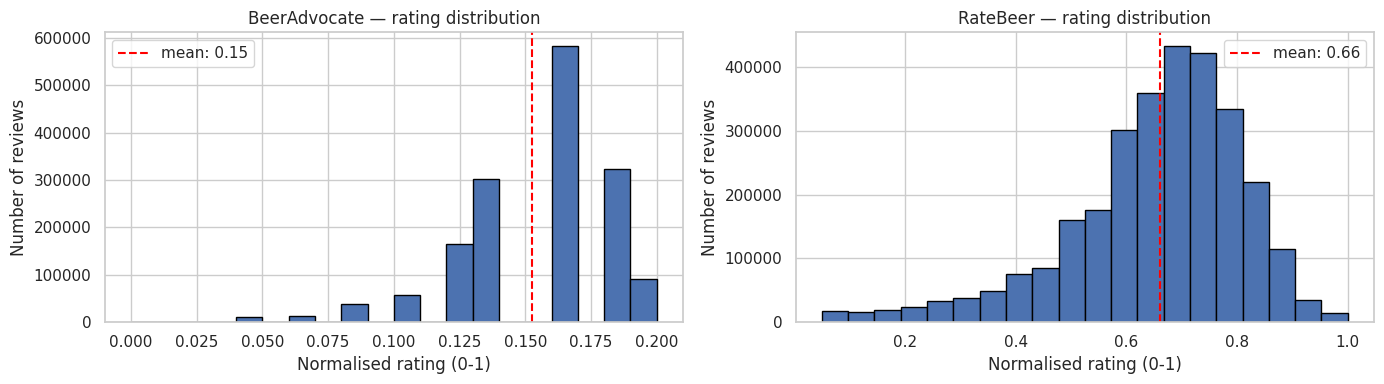

                  count   mean    std   min   25%   50%   75%  max
source                                                            
beeradvocate  1586614.0  0.153  0.029  0.00  0.14  0.16  0.18  0.2
ratebeer      2924163.0  0.660  0.168  0.05  0.60  0.70  0.75  1.0


In [12]:
# ── 5a. Rating distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (src, label) in zip(axes, [('beeradvocate', 'BeerAdvocate'), ('ratebeer', 'RateBeer')]):
    subset = df[df['source'] == src]['review/overall']
    ax.hist(subset, bins=20, edgecolor='black')
    ax.set_title(f'{label} — rating distribution')
    ax.set_xlabel('Normalised rating (0-1)')
    ax.set_ylabel('Number of reviews')
    ax.axvline(subset.mean(), color='red', linestyle='--',
               label=f'mean: {subset.mean():.2f}')
    ax.legend()
plt.tight_layout()
plt.show()
print(df.groupby('source')['review/overall'].describe().round(3))


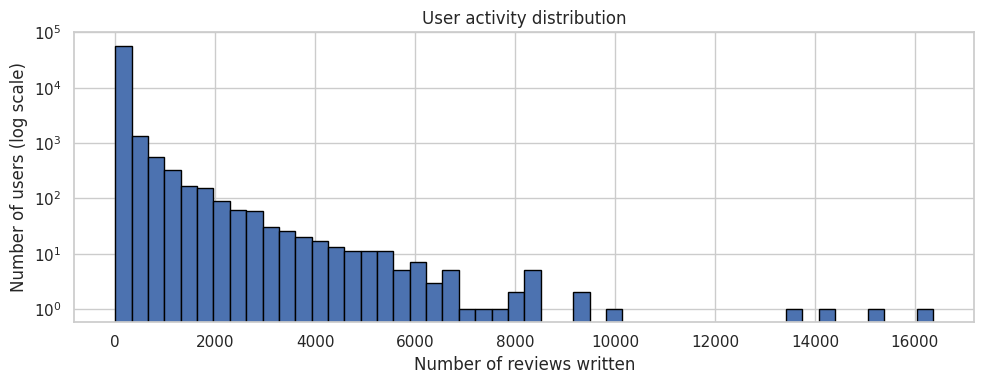

count    60786.0
mean        74.2
std        358.0
min          1.0
25%          1.0
50%          3.0
75%         17.0
max      16364.0
Name: review_count, dtype: float64
Users with <=  1 reviews: 18,888  (31.1%)
Users with <=  5 reviews: 36,045  (59.3%)
Users with <= 10 reviews: 42,081  (69.2%)


In [13]:
# ── 5b. User activity distribution ───────────────────────────────────────
user_activity = df.groupby('review/profileName').size().rename('review_count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_activity, bins=50, log=True, edgecolor='black')
ax.set_xlabel('Number of reviews written')
ax.set_ylabel('Number of users (log scale)')
ax.set_title('User activity distribution')
plt.tight_layout()
plt.show()

print(user_activity.describe().round(1))
for threshold in [1, 5, 10]:
    n   = (user_activity <= threshold).sum()
    pct = 100 * n / len(user_activity)
    print(f'Users with <= {threshold:>2} reviews: {n:>6,}  ({pct:.1f}%)')


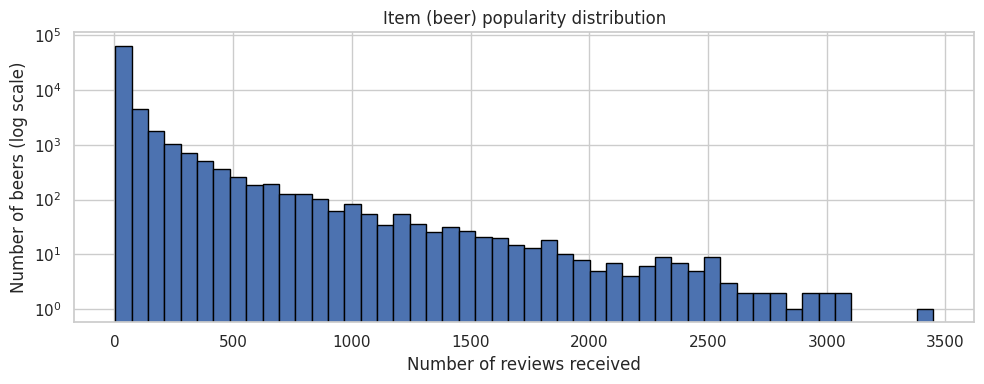

count    75476.0
mean        55.3
std        158.8
min          4.0
25%          7.0
50%         14.0
75%         35.0
max       3448.0
Name: review_count, dtype: float64
Beers with <=  1 reviews:      0  (0.0%)
Beers with <=  5 reviews:  8,071  (10.7%)
Beers with <= 10 reviews: 30,313  (40.2%)


In [22]:
# ── 5c. Item popularity distribution ─────────────────────────────────────
item_popularity = df.groupby('item_id').size().rename('review_count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(item_popularity, bins=50, log=True, edgecolor='black')
ax.set_xlabel('Number of reviews received')
ax.set_ylabel('Number of beers (log scale)')
ax.set_title('Item (beer) popularity distribution')
plt.tight_layout()
plt.show()

print(item_popularity.describe().round(1))
for threshold in [1, 5, 10]:
    n   = (item_popularity <= threshold).sum()
    pct = 100 * n / len(item_popularity)
    print(f'Beers with <= {threshold:>2} reviews: {n:>6,}  ({pct:.1f}%)')


In [23]:
# ── 5d. Sparsity ──────────────────────────────────────────────────────────
n_interactions = len(df)
possible       = n_users * n_items
sparsity       = 1 - (n_interactions / possible)

print(f'Users:             {n_users:>10,}')
print(f'Items:             {n_items:>10,}')
print(f'Interactions:      {n_interactions:>10,}')
print(f'Possible pairs:    {possible:>10,}')
print(f'Sparsity:          {sparsity:>10.4%}')


Users:                 26,540
Items:                 75,476
Interactions:       4,176,991
Possible pairs:    2,003,133,040
Sparsity:            99.7915%


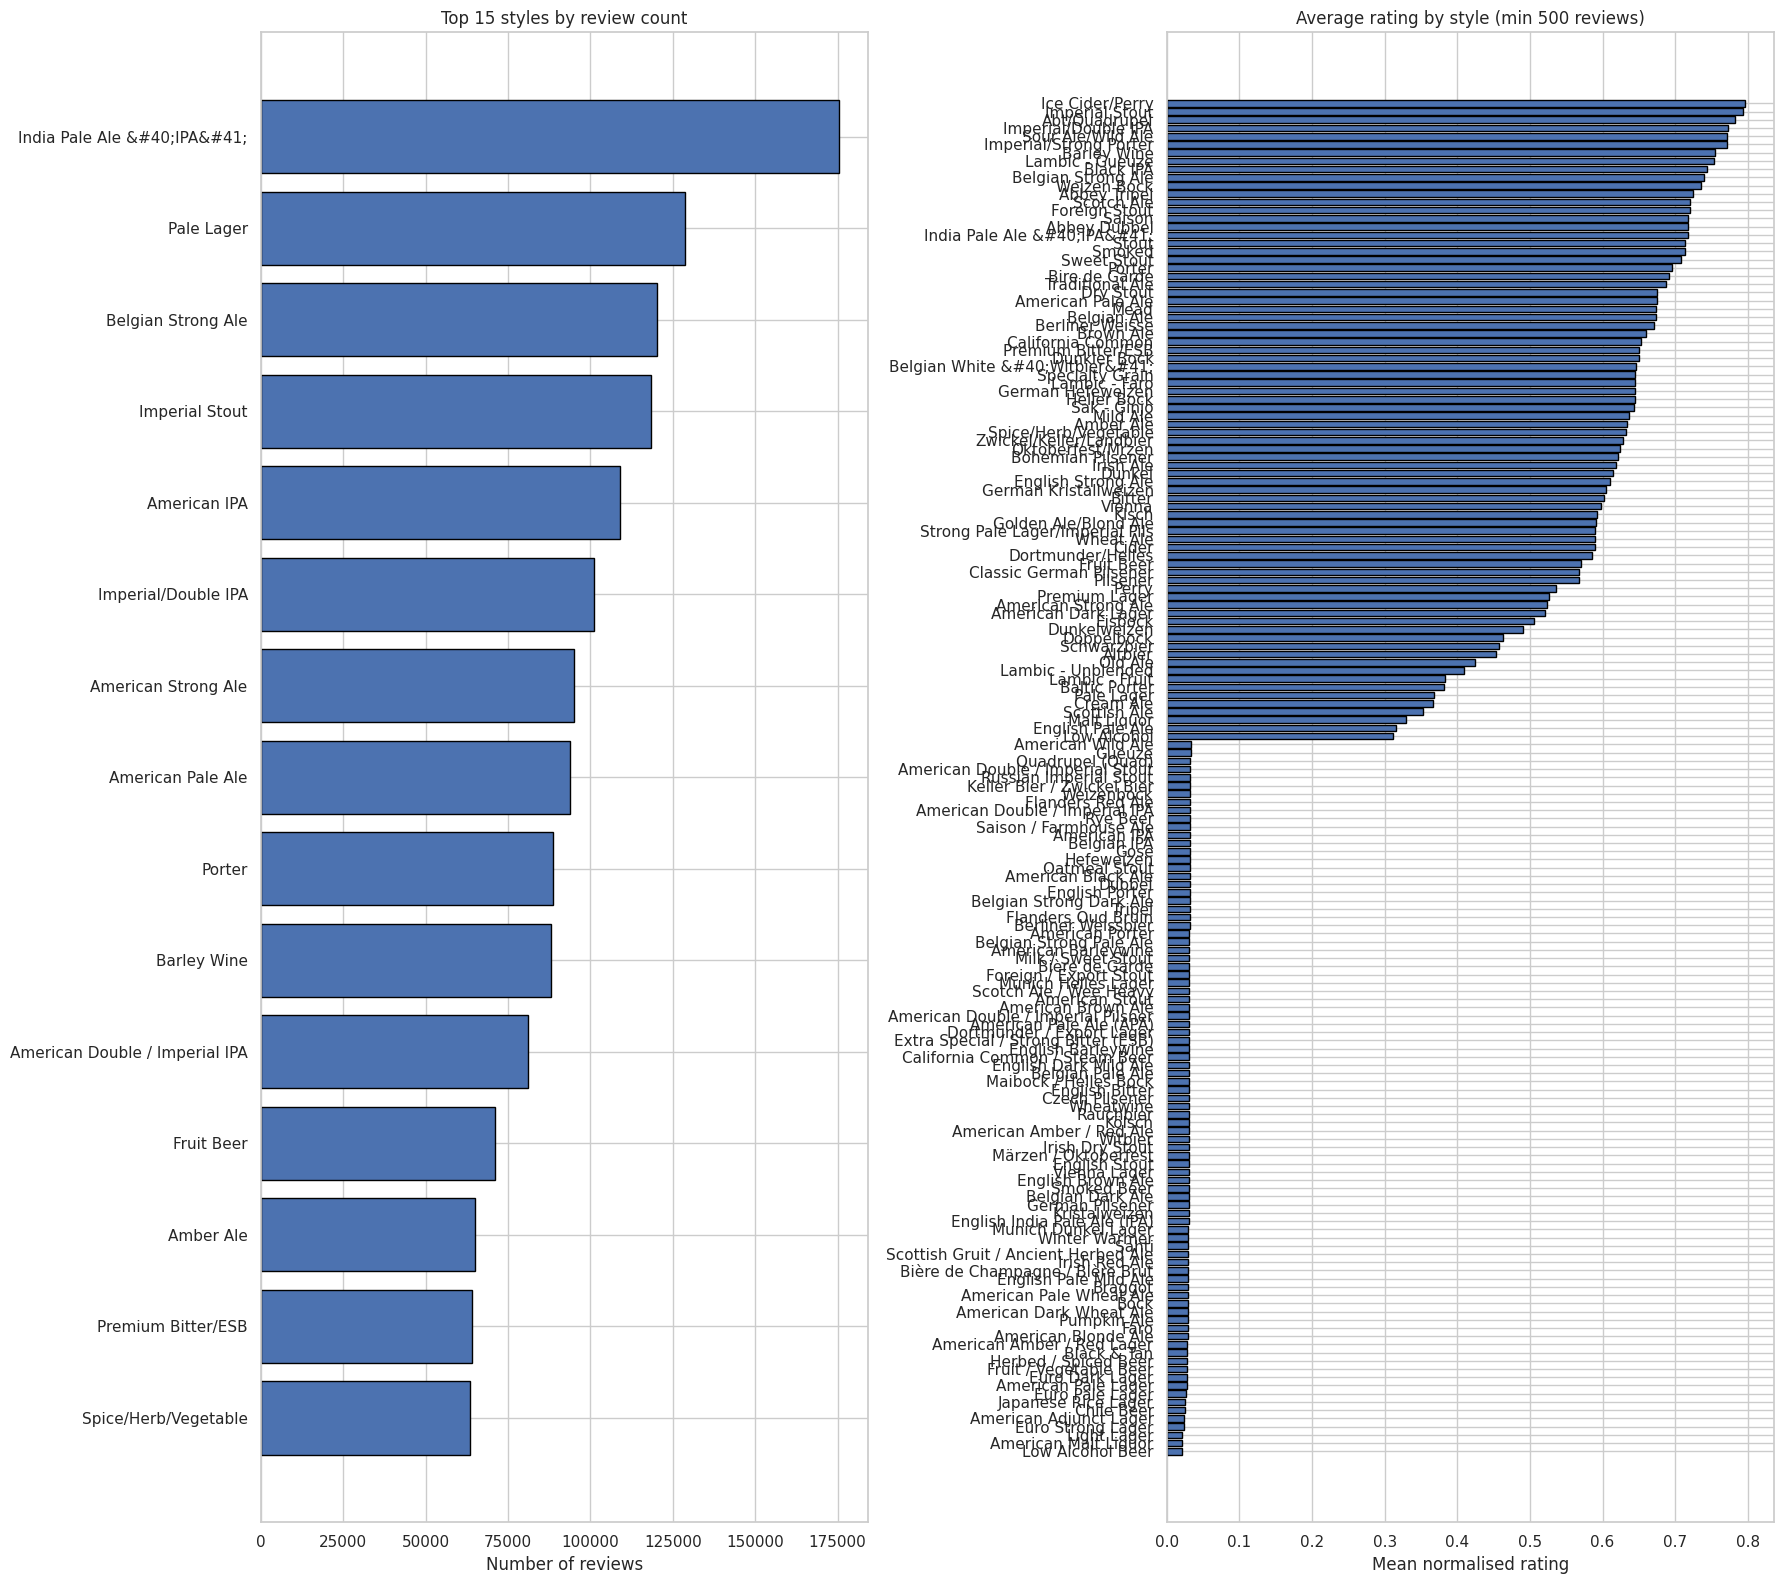

Total unique styles: 179


In [24]:
# ── 5e. Beer style distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 16))

top_styles = df['beer/style'].value_counts().head(15)
axes[0].barh(top_styles.index[::-1], top_styles.values[::-1], edgecolor='black')
axes[0].set_xlabel('Number of reviews')
axes[0].set_title('Top 15 styles by review count')

style_ratings = (
    df.groupby('beer/style')['review/overall']
    .agg(mean_rating='mean', review_count='count')
    .query('review_count >= 500')
    .sort_values('mean_rating', ascending=True)
)
axes[1].barh(style_ratings.index, style_ratings['mean_rating'], edgecolor='black')
axes[1].set_xlabel('Mean normalised rating')
axes[1].set_title('Average rating by style (min 500 reviews)')

plt.tight_layout()
plt.show()
print(f'Total unique styles: {df["beer/style"].nunique()}')


In [26]:
# ── 5f. Temporal analysis ─────────────────────────────────────────────────
df['year'] = df['review/time'].dt.year

reviews_per_year = (
    df.groupby(['year', 'source'])
    .size()
    .unstack(fill_value=0)
)

reviews_per_year.plot(kind='bar', figsize=(14, 5), edgecolor='black')
plt.title('Reviews per year by platform')
plt.xlabel('Year')
plt.ylabel('Number of reviews')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()
print(reviews_per_year)


AttributeError: Can only use .dt accessor with datetimelike values


## 6. Temporal Train / Validation / Test Split




In [27]:
# --- Per-user chronological 80/10/10 split ---
df_sorted = df.sort_values(['review/profileName', 'review/time']).reset_index(drop=True)

train_parts, val_parts, test_parts = [], [], []

MIN_USER_INTERACTIONS = 5  # optional safeguard

for _, g in df_sorted.groupby('review/profileName', sort=False):
    n = len(g)

    if n < MIN_USER_INTERACTIONS:
        # keep very short histories in train only
        train_parts.append(g)
        continue

    train_end = max(1, int(0.8 * n))
    val_end = max(train_end + 1, int(0.9 * n))

    # guard against empty splits
    if val_end >= n:
        val_end = n - 1
    if train_end >= val_end:
        train_end = val_end - 1

    train_parts.append(g.iloc[:train_end])
    val_parts.append(g.iloc[train_end:val_end])
    test_parts.append(g.iloc[val_end:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df   = pd.concat(val_parts, ignore_index=True) if val_parts else pd.DataFrame(columns=df.columns)
test_df  = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=df.columns)

print(f"Train: {len(train_df):,} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df):,} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df):,} ({len(test_df)/len(df):.1%})")

print(f"Train users: {train_df['review/profileName'].nunique()}")
print(f"Val users:   {val_df['review/profileName'].nunique()}")
print(f"Test users:  {test_df['review/profileName'].nunique()}")

Train: 3,329,055 (79.7%)
Val:   418,917 (10.0%)
Test:  429,019 (10.3%)
Train users: 26540
Val users:   26540
Test users:  26540


In [28]:
# --- Build mappings from TRAIN ONLY (prevents leakage) ---

train_users = sorted(train_df['review/profileName'].unique())
train_items = sorted(train_df['item_id'].unique())

user2idx = {u: i for i, u in enumerate(train_users)}
item2idx = {it: i for i, it in enumerate(train_items)}

# Filter val/test to only seen users/items
val_df = val_df[
    val_df['review/profileName'].isin(user2idx) &
    val_df['item_id'].isin(item2idx)
].copy()

test_df = test_df[
    test_df['review/profileName'].isin(user2idx) &
    test_df['item_id'].isin(item2idx)
].copy()

# Map indices
train_df['user_idx'] = train_df['review/profileName'].map(user2idx)
train_df['item_idx'] = train_df['item_id'].map(item2idx)

val_df['user_idx'] = val_df['review/profileName'].map(user2idx)
val_df['item_idx'] = val_df['item_id'].map(item2idx)

test_df['user_idx'] = test_df['review/profileName'].map(user2idx)
test_df['item_idx'] = test_df['item_id'].map(item2idx)

## 7. Baseline 1 — Popularity / Bayesian Average

In [29]:
C = train_df['review/overall'].mean()
m = 25

item_stats = (
    train_df.groupby('item_id')['review/overall']
    .agg(count='count', mean='mean')
    .assign(score=lambda x: (x['count'] * x['mean'] + m * C) / (x['count'] + m))
    .sort_values('score', ascending=False)
)
item_score_lookup = item_stats['score'].to_dict()

print(f'Global mean (C): {C:.4f}')
display(item_stats.head(10))


Global mean (C): 0.4395


,count,mean,score
item_id,,,
ratebeer_4934,1626,0.909994,0.902869
ratebeer_14232,1401,0.877231,0.869556
ratebeer_15917,1095,0.877123,0.867354
ratebeer_3214,1860,0.872070,0.866333
ratebeer_28173,392,0.885459,0.858722
ratebeer_8936,1267,0.866575,0.858310
ratebeer_8933,1382,0.865810,0.858235
ratebeer_4935,1191,0.866373,0.857596
ratebeer_43181,431,0.880626,0.856441


## 8. Dataset + DataLoaders (single clean version)

In [30]:
# --- Per-user chronological 80/10/10 split ---

df_sorted = df.sort_values(['review/profileName', 'review/time']).reset_index(drop=True)

train_parts, val_parts, test_parts = [], [], []

MIN_USER_INTERACTIONS = 5

for _, g in df_sorted.groupby('review/profileName', sort=False):
    n = len(g)

    # Keep very small histories in train only
    if n < MIN_USER_INTERACTIONS:
        train_parts.append(g)
        continue

    n_test = max(1, int(round(0.1 * n)))
    n_val  = max(1, int(round(0.1 * n)))
    n_train = n - n_val - n_test

    # safety checks
    if n_train < 1:
        n_train = n - 2
        n_val = 1
        n_test = 1

    train_parts.append(g.iloc[:n_train])
    val_parts.append(g.iloc[n_train:n_train + n_val])
    test_parts.append(g.iloc[n_train + n_val:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df   = pd.concat(val_parts, ignore_index=True)
test_df  = pd.concat(test_parts, ignore_index=True)

print(f"Train: {len(train_df):,} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df):,} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df):,} ({len(test_df)/len(df):.1%})")

print(f"Train users: {train_df['review/profileName'].nunique()}")
print(f"Val users:   {val_df['review/profileName'].nunique()}")
print(f"Test users:  {test_df['review/profileName'].nunique()}")

Train: 3,336,965 (79.9%)
Val:   420,013 (10.1%)
Test:  420,013 (10.1%)
Train users: 26540
Val users:   26540
Test users:  26540


## 9. Baseline 2 — Matrix Factorization

In [32]:
MF_CONFIG = {
    "n_factors": 48,
    "lr": 1e-3,
    "embed_reg": 5e-6,
    "bias_reg": 1e-7,
    "n_epochs": 20,
    "batch_size": 8192,
    "num_workers": 0,   # safer in notebooks; avoids Bad file descriptor
    "patience": 2,
    "min_delta": 1e-4,
    "grad_clip": 1.0,
}


In [33]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors=96, global_mean=0.0):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_mean = nn.Parameter(torch.tensor([global_mean], dtype=torch.float32), requires_grad=False)

        nn.init.normal_(self.user_factors.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.item_factors.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        u = self.user_factors(users)
        i = self.item_factors(items)
        dot = (u * i).sum(dim=1)
        ub = self.user_bias(users).squeeze(-1)
        ib = self.item_bias(items).squeeze(-1)
        preds = self.global_mean + ub + ib + dot
        return torch.clamp(preds, 0.0, 1.0)


global_mean = float(train_df['review/overall'].mean())

mf_model = MatrixFactorization(
    n_users=n_users,
    n_items=n_items,
    n_factors=MF_CONFIG['n_factors'],
    global_mean=global_mean,
).to(DEVICE)

optimizer = torch.optim.AdamW(mf_model.parameters(), lr=MF_CONFIG['lr'], weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)
criterion = nn.MSELoss()

print(mf_model)
print('Total parameters:', sum(p.numel() for p in mf_model.parameters()))


MatrixFactorization(
  (user_factors): Embedding(26540, 48)
  (item_factors): Embedding(75476, 48)
  (user_bias): Embedding(26540, 1)
  (item_bias): Embedding(75476, 1)
)
Total parameters: 4998785


In [34]:
# =========================
# Matrix Factorization Baseline
# Full block: config + model + train/eval
# Assumes these already exist:
#   - train_df, val_df, test_df
#   - DEVICE
#   - columns: user_idx, item_idx, review/overall
# =========================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# -------------------------
# 1) Sanity check rating scale
# -------------------------
print("Train rating range:", float(train_df["review/overall"].min()), float(train_df["review/overall"].max()))
print("Val rating range:  ", float(val_df["review/overall"].min()), float(val_df["review/overall"].max()))
print("Test rating range: ", float(test_df["review/overall"].min()), float(test_df["review/overall"].max()))

# This code expects ratings normalized to [0, 1].
# If not, normalize first:
# for df_part in [train_df, val_df, test_df]:
#     df_part["review/overall"] = df_part["review/overall"] / 5.0


# -------------------------
# 2) Config
# -------------------------
MF_CONFIG = {
    "n_factors": 48,
    "lr": 1e-3,
    "embed_reg": 5e-6,
    "bias_reg": 1e-7,
    "n_epochs": 20,
    "batch_size": 8192,
    "num_workers": 0,   # safer in notebooks; avoids Bad file descriptor
    "patience": 2,
    "min_delta": 1e-4,
    "grad_clip": 1.0,
}


# -------------------------
# 3) Counts
# -------------------------
n_users = int(train_df["user_idx"].max()) + 1
n_items = int(train_df["item_idx"].max()) + 1
global_mean = float(train_df["review/overall"].mean())

print(f"n_users: {n_users:,}")
print(f"n_items: {n_items:,}")
print(f"global_mean: {global_mean:.4f}")


# -------------------------
# 4) Dataset / Dataloader
# -------------------------
class RatingDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.users = torch.tensor(frame["user_idx"].values, dtype=torch.long)
        self.items = torch.tensor(frame["item_idx"].values, dtype=torch.long)
        self.ratings = torch.tensor(frame["review/overall"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


train_ds = RatingDataset(train_df)
val_ds = RatingDataset(val_df)
test_ds = RatingDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=MF_CONFIG["batch_size"],
    shuffle=True,
    num_workers=MF_CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=MF_CONFIG["batch_size"] * 2,
    shuffle=False,
    num_workers=MF_CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=MF_CONFIG["batch_size"] * 2,
    shuffle=False,
    num_workers=MF_CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches:   {len(val_loader):,}")
print(f"Test batches:  {len(test_loader):,}")


# -------------------------
# 5) Model
# -------------------------
class MatrixFactorization(nn.Module):
    def __init__(self, n_users: int, n_items: int, n_factors: int = 48, global_mean: float = 0.5):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)

        self.global_mean = nn.Parameter(
            torch.tensor([global_mean], dtype=torch.float32),
            requires_grad=False
        )

        nn.init.normal_(self.user_factors.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.item_factors.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        u = self.user_factors(users)               # [B, K]
        i = self.item_factors(items)               # [B, K]
        dot = (u * i).sum(dim=1)                   # [B]
        ub = self.user_bias(users).squeeze(-1)     # [B]
        ib = self.item_bias(items).squeeze(-1)     # [B]

        raw = self.global_mean + dot + ub + ib
        preds = torch.sigmoid(raw)                 # bounded to [0, 1]
        return preds


mf_model = MatrixFactorization(
    n_users=n_users,
    n_items=n_items,
    n_factors=MF_CONFIG["n_factors"],
    global_mean=global_mean,
).to(DEVICE)

print(mf_model)
print("Total parameters:", sum(p.numel() for p in mf_model.parameters()))


# -------------------------
# 6) Optimizer / Scheduler / Loss
# -------------------------
optimizer = torch.optim.Adam(
    mf_model.parameters(),
    lr=MF_CONFIG["lr"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

criterion = nn.MSELoss()


# -------------------------
# 7) Regularization helper
# -------------------------
def batch_regularization(
    model: MatrixFactorization,
    users: torch.Tensor,
    items: torch.Tensor,
    embed_reg: float = 5e-6,
    bias_reg: float = 1e-7,
) -> torch.Tensor:
    uf = model.user_factors(users)
    it = model.item_factors(items)
    ub = model.user_bias(users)
    ib = model.item_bias(items)

    reg = embed_reg * (uf.pow(2).sum() + it.pow(2).sum()) / len(users)
    reg = reg + bias_reg * (ub.pow(2).sum() + ib.pow(2).sum()) / len(users)
    return reg


# -------------------------
# 8) Train / Eval functions
# -------------------------
def train_one_epoch(loader, model, optimizer):
    model.train()
    total_mse = 0.0
    total_n = 0

    for users, items, ratings in loader:
        users = users.to(DEVICE, non_blocking=True)
        items = items.to(DEVICE, non_blocking=True)
        ratings = ratings.to(DEVICE, non_blocking=True)

        preds = model(users, items)
        mse = criterion(preds, ratings)
        reg = batch_regularization(
            model,
            users,
            items,
            embed_reg=MF_CONFIG["embed_reg"],
            bias_reg=MF_CONFIG["bias_reg"],
        )
        loss = mse + reg

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MF_CONFIG["grad_clip"])
        optimizer.step()

        total_mse += mse.item() * len(ratings)
        total_n += len(ratings)

    return np.sqrt(total_mse / total_n)


@torch.no_grad()
def evaluate_rmse(loader, model):
    model.eval()
    total_se = 0.0
    total_n = 0

    for users, items, ratings in loader:
        users = users.to(DEVICE, non_blocking=True)
        items = items.to(DEVICE, non_blocking=True)
        ratings = ratings.to(DEVICE, non_blocking=True)

        preds = model(users, items)
        total_se += ((preds - ratings) ** 2).sum().item()
        total_n += len(ratings)

    return np.sqrt(total_se / total_n)


@torch.no_grad()
def predict_df(model, frame: pd.DataFrame, batch_size: int = 16384) -> np.ndarray:
    model.eval()
    preds_all = []

    users = torch.tensor(frame["user_idx"].values, dtype=torch.long)
    items = torch.tensor(frame["item_idx"].values, dtype=torch.long)

    for start in range(0, len(frame), batch_size):
        end = min(start + batch_size, len(frame))
        u = users[start:end].to(DEVICE)
        i = items[start:end].to(DEVICE)
        preds = model(u, i).cpu().numpy()
        preds_all.append(preds)

    return np.concatenate(preds_all, axis=0)


def rmse_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.mean(np.abs(y_true - y_pred)))


# -------------------------
# 9) Training loop
# -------------------------
history = {
    "epoch": [],
    "train_loss_rmse": [],
    "train_rmse": [],
    "val_rmse": [],
    "lr": [],
}

best_val_rmse = float("inf")
best_state = None
epochs_no_improve = 0

for epoch in range(1, MF_CONFIG["n_epochs"] + 1):
    train_loss_rmse = train_one_epoch(train_loader, mf_model, optimizer)
    train_rmse = evaluate_rmse(train_loader, mf_model)
    val_rmse = evaluate_rmse(val_loader, mf_model)

    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_rmse)
    new_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss_rmse"].append(train_loss_rmse)
    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)
    history["lr"].append(new_lr)

    print(
        f"Epoch {epoch:02d} | "
        f"train(loss) RMSE={train_loss_rmse:.4f} | "
        f"train RMSE={train_rmse:.4f} | "
        f"val RMSE={val_rmse:.4f} | "
        f"lr={new_lr:.2e}"
    )

    if new_lr != prev_lr:
        print(f"LR reduced: {prev_lr:.2e} -> {new_lr:.2e}")

    if val_rmse < best_val_rmse - MF_CONFIG["min_delta"]:
        best_val_rmse = val_rmse
        best_state = copy.deepcopy(mf_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= MF_CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}. Best val RMSE = {best_val_rmse:.4f}")
            break

if best_state is not None:
    mf_model.load_state_dict(best_state)


# -------------------------
# 10) Final evaluation
# -------------------------
best_train_rmse = evaluate_rmse(train_loader, mf_model)
best_val_rmse = evaluate_rmse(val_loader, mf_model)
best_test_rmse = evaluate_rmse(test_loader, mf_model)

test_preds = predict_df(mf_model, test_df)
test_truth = test_df["review/overall"].values

best_test_mae = mae_score(test_truth, test_preds)

print("\nFinal MF results")
print(f"Train RMSE: {best_train_rmse:.4f}")
print(f"Val RMSE:   {best_val_rmse:.4f}")
print(f"Test RMSE:  {best_test_rmse:.4f}")
print(f"Test MAE:   {best_test_mae:.4f}")


# -------------------------
# 11) Save predictions back to test_df (optional)
# -------------------------
test_df = test_df.copy()
test_df["mf_pred"] = test_preds

display(test_df[[
    "review/profileName",
    "item_id",
    "review/overall",
    "mf_pred"
]].head())


# -------------------------
# 12) Training history table (optional)
# -------------------------
history_df = pd.DataFrame(history)
display(history_df)

Train rating range: 0.0 1.0
Val rating range:   0.008 1.0
Test rating range:  0.008 1.0
n_users: 26,540
n_items: 75,476
global_mean: 0.4392
Train batches: 408
Val batches:   26
Test batches:  26
MatrixFactorization(
  (user_factors): Embedding(26540, 48)
  (item_factors): Embedding(75476, 48)
  (user_bias): Embedding(26540, 1)
  (item_bias): Embedding(75476, 1)
)
Total parameters: 4998785
Epoch 01 | train(loss) RMSE=0.2709 | train RMSE=0.1395 | val RMSE=0.1558 | lr=1.00e-03
Epoch 02 | train(loss) RMSE=0.1164 | train RMSE=0.0986 | val RMSE=0.1099 | lr=1.00e-03
Epoch 03 | train(loss) RMSE=0.0944 | train RMSE=0.0881 | val RMSE=0.0975 | lr=1.00e-03
Epoch 04 | train(loss) RMSE=0.0871 | train RMSE=0.0831 | val RMSE=0.0926 | lr=1.00e-03
Epoch 05 | train(loss) RMSE=0.0830 | train RMSE=0.0795 | val RMSE=0.0904 | lr=1.00e-03
Epoch 06 | train(loss) RMSE=0.0798 | train RMSE=0.0764 | val RMSE=0.0893 | lr=1.00e-03
Epoch 07 | train(loss) RMSE=0.0768 | train RMSE=0.0735 | val RMSE=0.0888 | lr=1.00e-03

,review/profileName,item_id,review/overall,mf_pred
0,,beeradvocate_1672,0.032,0.005151
1,,beeradvocate_50429,0.036,0.015461
2,,beeradvocate_409,0.032,0.005777
3,,beeradvocate_155,0.036,0.003007
4,,beeradvocate_156,0.036,0.003554


,epoch,train_loss_rmse,train_rmse,val_rmse,lr
0,1,0.270875,0.139531,0.155780,0.0010
1,2,0.116436,0.098579,0.109851,0.0010
2,3,0.094379,0.088065,0.097503,0.0010
3,4,0.087108,0.083079,0.092613,0.0010
4,5,0.083011,0.079547,0.090363,0.0010
5,6,0.079785,0.076434,0.089268,0.0010
6,7,0.076815,0.073501,0.088775,0.0010
7,8,0.073977,0.070694,0.088651,0.0010
8,9,0.071264,0.068021,0.088751,0.0010
9,10,0.068703,0.065549,0.088984,0.0005


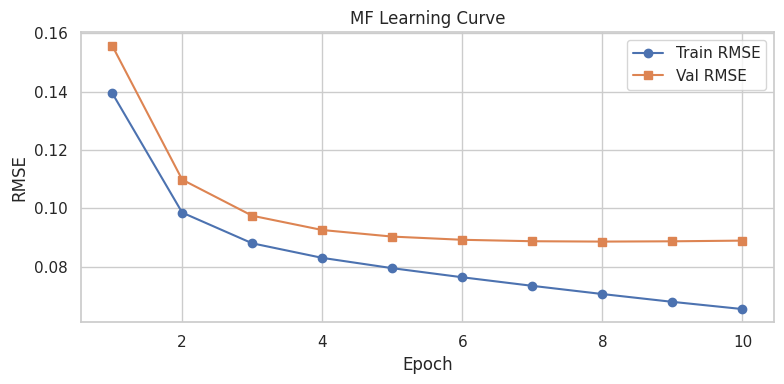

Best val RMSE: 0.0887


In [35]:
epochs = range(1, len(history['train_rmse']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train_rmse'], marker='o', label='Train RMSE')
plt.plot(epochs, history['val_rmse'], marker='s', label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('MF Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best val RMSE: {min(history['val_rmse']):.4f}")


## 10. Extra sanity baseline — User + Item Bias

In [36]:
user_mean = train_df.groupby('review/profileName')['review/overall'].mean()
item_mean = train_df.groupby('item_id')['review/overall'].mean()

user_bias = (user_mean - global_mean).to_dict()
item_bias = (item_mean - global_mean).to_dict()

def bias_pred(df_eval):
    preds = []
    for _, row in df_eval.iterrows():
        u = row['review/profileName']
        i = row['item_id']
        pred = global_mean + user_bias.get(u, 0.0) + item_bias.get(i, 0.0)
        preds.append(np.clip(pred, 0.0, 1.0))
    return np.array(preds)


## 11. Rating Evaluation

In [37]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def eval_rating(name, pred_fn, df_eval):
    y_true = df_eval['review/overall'].values
    y_pred = pred_fn(df_eval)
    return {'model': name, 'RMSE': rmse(y_true, y_pred), 'MAE': mae(y_true, y_pred)}


def pop_pred(df_eval):
    return df_eval['item_id'].map(item_score_lookup).fillna(C).values


@torch.no_grad()
def mf_pred(df_eval):
    eval_ds = RatingDataset(df_eval)
    eval_loader = DataLoader(
        eval_ds,
        batch_size=16384,
        shuffle=False,
        num_workers=2,
        pin_memory=(DEVICE.type == 'cuda')
    )
    preds = []
    for users, items, _ in eval_loader:
        users = users.to(DEVICE, non_blocking=True)
        items = items.to(DEVICE, non_blocking=True)
        preds.append(mf_model(users, items).cpu().numpy())
    return np.concatenate(preds)

rating_results = [
    eval_rating('Popularity', pop_pred, test_df),
    eval_rating('User+Item Bias', bias_pred, test_df),
    eval_rating('MF (PyTorch)', mf_pred, test_df),
]

rating_df = pd.DataFrame(rating_results).set_index('model')
display(rating_df.round(4))


,RMSE,MAE
model,,
Popularity,0.1625,0.1242
User+Item Bias,0.1877,0.1433
MF (PyTorch),0.0966,0.0615


## 12. Ranking Evaluation


## 13. Final Notes for Phase 1

Recommended reporting points:
- use the temporal split as the shared evaluation split
- report both rating prediction and top-N metrics
- compare at least popularity vs MF
- if popularity remains strong, discuss data sparsity and cold-start effects
- keep this notebook as the shared foundation before the three advanced variants diverge
